# **Predict temperature 30 days ahead using a LSTM neural network**

# Get the KNMI data

In [18]:
# import libraries
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from datetime import date
import requests
from io import BytesIO
import tensorflow as tf
from tensorflow import keras
import math

In [19]:
# read the KNMI data
# this dataset contains all daily weather measurement data in de Bilt (close to Utrecht), starting on the 1st of januari 1901

# This is the github URL (Johan Looijenga's Github) to read the raw .xlsx file
url = 'https://github.com/jolo-maker/DataScience/raw/refs/heads/main/KNMI_1900_de_bilt.xlsx'

# Fetch the content from the URL
response = requests.get(url)
response.raise_for_status()  # Ensure the request was successful

# Load the Excel file into a pandas DataFrame
sheet_name = 'Data 1900-2024'  # Specify the sheet name
knmi_data = pd.read_excel(BytesIO(response.content), sheet_name=sheet_name)

# Display the DataFrame
knmi_data

,# STN,YYYYMMDD,DDVEC,FHVEC,FG,FHX,FHXH,FHN,FHNH,FXX,...,VVNH,VVX,VVXH,NG,UG,UX,UXH,UN,UNH,EV24
0,260,19010101,,,,,,,,,...,,,,,66,,,,,
1,260,19010102,,,,,,,,,...,,,,,86,,,,,
2,260,19010103,,,,,,,,,...,,,,,89,,,,,
3,260,19010104,,,,,,,,,...,,,,,79,,,,,
4,260,19010105,,,,,,,,,...,,,,,65,,,,,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45259,260,20241130,165,28,30,40,2,20,16,70,...,4,75,11,5,82,91,1,72,11,5
45260,260,20241201,165,36,38,50,13,20,1,90,...,23,82,12,8,79,96,23,64,12,6
45261,260,20241202,213,38,40,50,2,30,16,90,...,4,70,12,8,92,97,6,85,15,2
45262,260,20241203,304,20,23,40,1,10,17,100,...,5,81,13,7,82,93,24,63,13,4


In [20]:
# Check on column names
print(knmi_data.columns)

Index(['# STN', 'YYYYMMDD', 'DDVEC', 'FHVEC', '   FG', '  FHX', ' FHXH',
       '  FHN', ' FHNH', '  FXX', ' FXXH', '   TG', '   TN', '  TNH', '   TX',
       '  TXH', 'T10N', 'T10NH', '   SQ', '   SP', '    Q', '   DR', '   RH',
       '  RHX', ' RHXH', '   PG', '   PX', '  PXH', '   PN', '  PNH', '  VVN',
       ' VVNH', '  VVX', ' VVXH', '   NG', '   UG', '   UX', '  UXH', '   UN',
       '  UNH', 'EV24'],
      dtype='object')


In [21]:
# Some columns contain spaces in the original KNMI data, let's remove these spaces
# Strip leading and trailing spaces from all column names
knmi_data.columns = knmi_data.columns.str.strip()
print(knmi_data.columns)

Index(['# STN', 'YYYYMMDD', 'DDVEC', 'FHVEC', 'FG', 'FHX', 'FHXH', 'FHN',
       'FHNH', 'FXX', 'FXXH', 'TG', 'TN', 'TNH', 'TX', 'TXH', 'T10N', 'T10NH',
       'SQ', 'SP', 'Q', 'DR', 'RH', 'RHX', 'RHXH', 'PG', 'PX', 'PXH', 'PN',
       'PNH', 'VVN', 'VVNH', 'VVX', 'VVXH', 'NG', 'UG', 'UX', 'UXH', 'UN',
       'UNH', 'EV24'],
      dtype='object')


In [22]:
# We want to limit the data to start in the year 2020 up until the last data (almost 5 years of daily temperatures)
# We want to convert the YYYYMMDD into
# We also want to look at maximum daily temperature only (column 'TX')
# Since the maximum temperature is in 0,1 Celsius, we want to divide by 10 to get the maximum temperature in Celsius

# Filter rows based on the date range
filtered_data = knmi_data[(knmi_data['YYYYMMDD'] >= 20200101) & (knmi_data['YYYYMMDD'] <= 20241204)].copy()

# Ensure the date column is converted to datetime for proper plotting
filtered_data['Date'] = pd.to_datetime(filtered_data['YYYYMMDD'], format='%Y%m%d')

# Select only the 'Date' and 'TX' columns
knmi_temp = filtered_data[['Date', 'TX']].copy()

# Set 'TX' to float first, because result will not be integer anymore
# Divide the 'TX' column values by 10
knmi_temp['TX'] = knmi_temp['TX'].astype(float)
knmi_temp.loc[:, 'TX'] = knmi_temp['TX'] / 10

# Display the resulting DataFrame
knmi_temp

,Date,TX
43464,2020-01-01,1.8
43465,2020-01-02,7.4
43466,2020-01-03,9.9
43467,2020-01-04,8.1
43468,2020-01-05,7.6
...,...,...
45259,2024-11-30,6.8
45260,2024-12-01,8.5
45261,2024-12-02,11.5
45262,2024-12-03,8.4


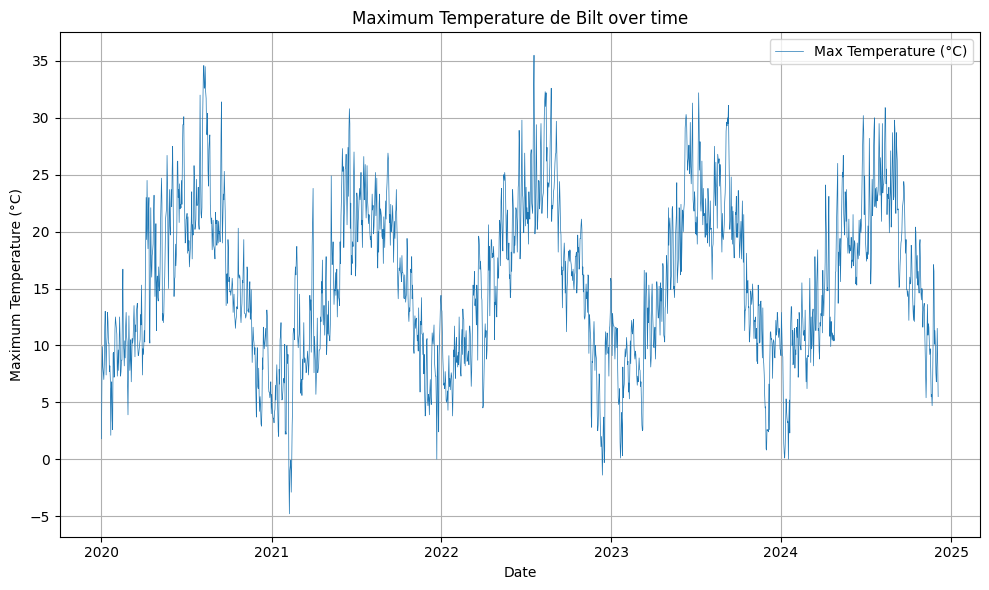

In [23]:
# Plot the maximum temperature

plt.figure(figsize=(10, 6))
plt.plot(knmi_temp['Date'], knmi_temp['TX'], label='Max Temperature (°C)', linewidth=0.5)
plt.title('Maximum Temperature de Bilt over time')
plt.xlabel('Date')
plt.ylabel('Maximum Temperature (°C)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

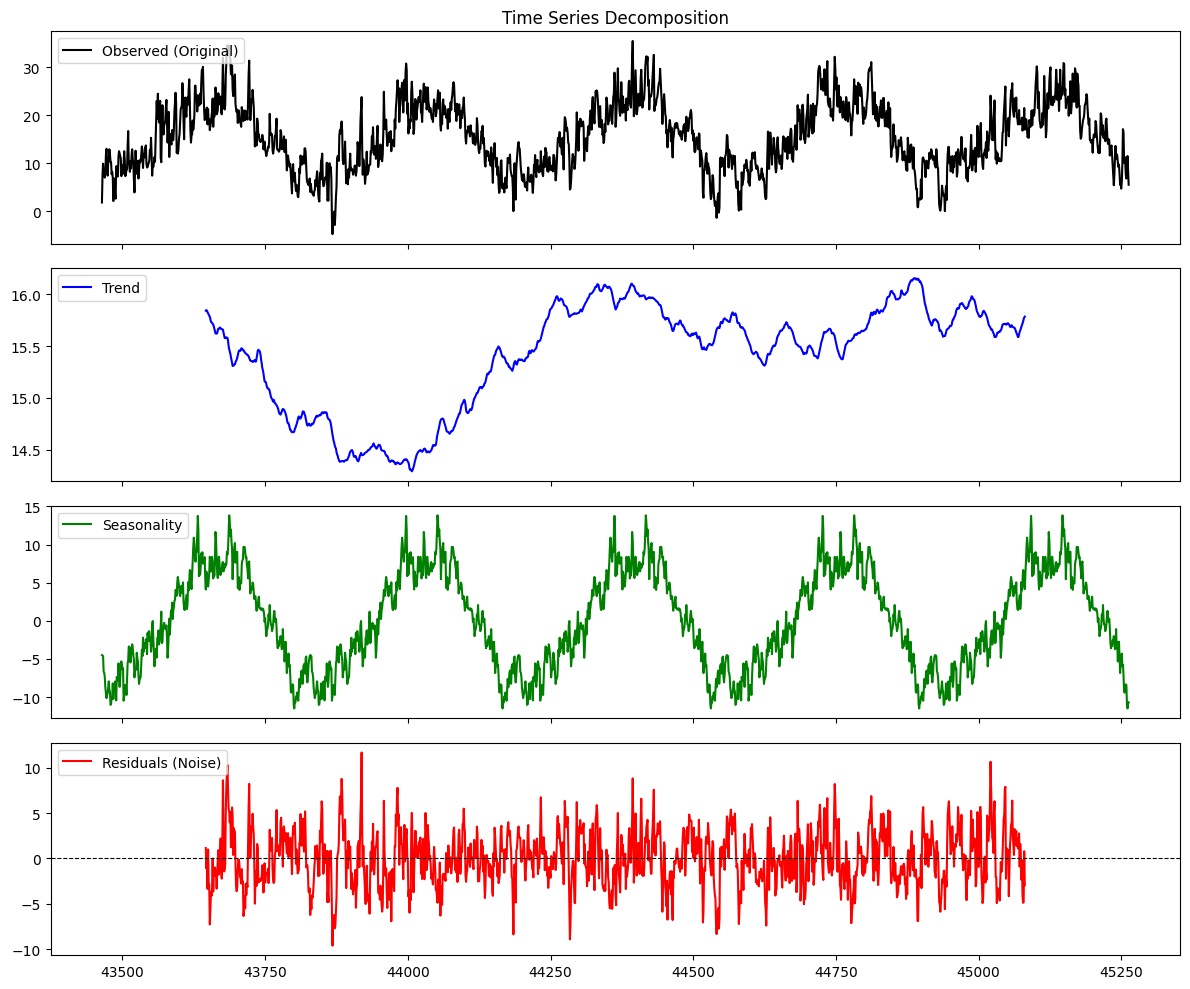

In [24]:
from statsmodels.tsa.seasonal import seasonal_decompose
decomposition = seasonal_decompose(knmi_temp['TX'], model='additive', period=365)

# --- 3. Plotting the Components ---
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

# Plot Observed (Original Data)
ax1.plot(decomposition.observed, label='Observed (Original)', color='black')
ax1.legend(loc='upper left')
ax1.set_title('Time Series Decomposition')

# Plot Trend (Static Growth)
ax2.plot(decomposition.trend, label='Trend', color='blue')
ax2.legend(loc='upper left')

# Plot Seasonality
ax3.plot(decomposition.seasonal, label='Seasonality', color='green')
ax3.legend(loc='upper left')

# Plot Residuals (Noise)
ax4.plot(decomposition.resid, label='Residuals (Noise)', color='red')
ax4.legend(loc='upper left')
# Add a horizontal line at 0 for residuals
ax4.axhline(0, color='black', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.show()

# preping the data

In [25]:
def Sliding_window(data_input, data_output, input_width, label_width):
    X,y = [],[]

    #the first inputs and last labels can't be compleat so the sould be sciped
    Result_len = len(data_input) - input_width - label_width +1
    
    for i in range(Result_len):
        X.append(data_input[i:i+input_width])
        y.append(data_output[i+input_width: i+input_width+label_width])

    return np.array(X), np.array(y)



def split_time_series_dataframe(df, train_ratio=0.8, n_test_samples=1):

    total_len = len(df)
    n_train = int(total_len * train_ratio)
    n_test = n_test_samples
    n_validate = total_len - n_train - n_test
    
    # Safety check
    if n_validate < 0:
        raise ValueError("Train ratio + test samples result in no validation set!")

    # 2. Calculate indices (split points)
    i_train = n_train 
    i_validate = n_train + n_validate 
    i_test = n_train + n_validate + n_test 
    
    # 3. Slice the DataFrame using .iloc for integer-position based indexing
    df_train = df.iloc[0:i_train].copy()
    df_validate = df.iloc[i_train:i_validate].copy()
    df_test = df.iloc[i_validate:i_test].copy()
    
    # Print shapes to verify
    print(f"Total samples: {total_len}")
    print(f"Train set:    {df_train.shape}")
    print(f"Validate set: {df_validate.shape}")
    print(f"Test set:     {df_test.shape}")
    
    return df_train, df_validate, df_test

In [26]:
history_size = 60   
target_size = 30   

In [27]:
# add month
knmi_temp['month_sin'] = np.sin(2* np.pi * knmi_temp['Date'].dt.month /12)
knmi_temp['month_cos'] = np.cos(2* np.pi * knmi_temp['Date'].dt.month /12)

# splitting


In [28]:
# Split data
df_train, df_val, df_test= split_time_series_dataframe(knmi_temp,n_test_samples=1*(history_size+target_size))

Total samples: 1800
Train set:    (1440, 4)
Validate set: (270, 4)
Test set:     (90, 4)


# scaling

In [29]:
from sklearn. preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(df_train[['TX']])

df_train.loc[:, ['TX']] = scaler.transform(df_train[['TX']])
df_val.loc[:, ['TX']]   = scaler.transform(df_val[['TX']])
df_test.loc[:, ['TX']]  = scaler.transform(df_test[['TX']])

# Create array's

We create test, validatioin and test stets with arrays in them in the shape of 60 windows from the past and 30 from the future

In [30]:
cols = ['TX', 'month_sin', 'month_cos']

X_train, y_train = Sliding_window(df_train[cols].values,df_train['TX'].values, history_size, target_size)
X_val, y_val     = Sliding_window(df_val[cols].values, df_val['TX'].values, history_size, target_size)
X_test, y_test   = Sliding_window(df_test[cols].values, df_test['TX'].values, history_size, target_size)

In [31]:
INPUT_SHAPE = (X_train.shape[1], X_train.shape[2]) 
OUTPUT_UNITS = y_train.shape[1] 

results_summary = []

# defining models

In [32]:
models = [
     keras.Sequential([
            keras.layers.Input(shape=INPUT_SHAPE),
            keras.layers.SimpleRNN(64, activation='relu'),
            keras.layers.Dense(OUTPUT_UNITS)
        ], name="Simple_RNN"),

     keras.Sequential([
            keras.layers.Input(shape=INPUT_SHAPE),
            keras.layers.LSTM(64, activation='relu'),
            keras.layers.Dense(OUTPUT_UNITS)
        ], name="LSTM_Vanilla"),
        
    keras.Sequential([
            keras.layers.Input(shape=INPUT_SHAPE),
            keras.layers.LSTM(64, activation='relu', return_sequences=True),
            keras.layers.LSTM(32, activation='relu'), 
            keras.layers.Dense(OUTPUT_UNITS)
        ], name="LSTM_Stacked"),

        keras.Sequential([
            keras.layers.Input(shape=INPUT_SHAPE),
            keras.layers.LSTM(64, activation='relu', return_sequences=True),
            keras.layers.LSTM(32, activation='relu', return_sequences=True),
            keras.layers.LSTM(16, activation='relu', return_sequences=True),
            keras.layers.LSTM(8, activation='relu'), 
            keras.layers.Dense(OUTPUT_UNITS)
        ], name="LSTM_big"),

        keras.Sequential([
            keras.layers.Input(shape=INPUT_SHAPE),
            keras.layers.SimpleRNN(64, activation='tanh'),
            keras.layers.Dense(OUTPUT_UNITS)
        ], name="Simple_RNN_tanh_tanh"),

     keras.Sequential([
            keras.layers.Input(shape=INPUT_SHAPE),
            keras.layers.LSTM(64, activation='tanh'),
            keras.layers.Dense(OUTPUT_UNITS)
        ], name="LSTM_Vanilla_tanh"),
        
    keras.Sequential([
            keras.layers.Input(shape=INPUT_SHAPE),
            keras.layers.LSTM(64, activation='tanh', return_sequences=True),
            keras.layers.LSTM(32, activation='tanh'), 
            keras.layers.Dense(OUTPUT_UNITS)
        ], name="LSTM_Stacked_tanh"),

        keras.Sequential([
            keras.layers.Input(shape=INPUT_SHAPE),
            keras.layers.LSTM(64, activation='tanh', return_sequences=True),
            keras.layers.LSTM(32, activation='tanh', return_sequences=True),
            keras.layers.LSTM(16, activation='tanh', return_sequences=True),
            keras.layers.LSTM(8, activation='tanh'), 
            keras.layers.Dense(OUTPUT_UNITS)
        ], name="LSTM_big_tanh"),

        keras.Sequential([
            keras.layers.Input(shape=INPUT_SHAPE),
            keras.layers.LSTM(256, activation='tanh', return_sequences=True),
            keras.layers.LSTM(128, activation='tanh', return_sequences=True),
            keras.layers.LSTM(64, activation='tanh', return_sequences=True),
            keras.layers.LSTM(32, activation='tanh', return_sequences=True),
            keras.layers.LSTM(16, activation='tanh', return_sequences=True),
            keras.layers.LSTM(8, activation='tanh'), 
            keras.layers.Dense(OUTPUT_UNITS)
        ], name="LSTM_huge"),

        keras.Sequential([
            keras.layers.Input(shape=INPUT_SHAPE),
            keras.layers.LSTM(64, activation='tanh', return_sequences=True),
            keras.layers.LSTM(64, activation='tanh', return_sequences=True),
            keras.layers.LSTM(64, activation='tanh', return_sequences=True),
            keras.layers.LSTM(64, activation='tanh', return_sequences=True),
            keras.layers.LSTM(64, activation='tanh', return_sequences=True),
            keras.layers.LSTM(64, activation='tanh', return_sequences=True),
            keras.layers.LSTM(64, activation='tanh', return_sequences=True),
            keras.layers.LSTM(64, activation='tanh', return_sequences=True),
            keras.layers.LSTM(64, activation='tanh', return_sequences=True),
            keras.layers.LSTM(64, activation='tanh', return_sequences=True),
            keras.layers.LSTM(64, activation='tanh', return_sequences=True),
            keras.layers.LSTM(64, activation='tanh', return_sequences=True),
            keras.layers.LSTM(64, activation='tanh', return_sequences=True),
            keras.layers.LSTM(64, activation='tanh', return_sequences=True),
            keras.layers.LSTM(64, activation='tanh', return_sequences=True),
            keras.layers.LSTM(64, activation='tanh', return_sequences=True),
            keras.layers.LSTM(64, activation='tanh', return_sequences=True),
            keras.layers.LSTM(64, activation='tanh'), 
            keras.layers.Dense(OUTPUT_UNITS)
        ], name="LSTM_biggest"),
        
]

# Training and evaluating

In [33]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

def train_and_evaluate(model, X_train, y_train, X_val, y_val, X_test, y_test, scaler):
    print(f"\n{'='*40}")
    print(f"Training Model: {model.name}")
    print(f"{'='*40}")

    # 1. Plot Model Architecture
    try:
        keras.utils.plot_model(model, to_file=f'{model.name}_architecture.png', show_shapes=True)
        print(f"Model architecture saved as {model.name}_architecture.png")
    except Exception as e:
        print(f"Could not plot model (Graphviz might be missing): {e}")

    # 2. Compile and Train
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    
    # EarlyStopping prevents overfitting
    early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=200,            
        batch_size=64,
        callbacks=[early_stop],
        verbose=1
    )

    # 3. Plot Training History
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # --- Graph 1: Loss (MSE) ---
    axes[0].plot(history.history['loss'], label='Train Loss (MSE)')
    axes[0].plot(history.history['val_loss'], label='Val Loss (MSE)')
    axes[0].set_title(f'{model.name} - Loss (MSE)')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True)
    
    # --- Graph 2: Metric (MAE - Average Error) ---
    axes[1].plot(history.history['mae'], label='Train MAE')
    axes[1].plot(history.history['val_mae'], label='Val MAE')
    axes[1].set_title(f'{model.name} - Mean Absolute Error')
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('Error (in normalized units)')
    axes[1].legend()
    axes[1].grid(True)
    
    plt.tight_layout()
    plt.show()

    # 4. Evaluation & Statistics (Converted to Degrees)
    # Evaluate on Test Set (Scaled)
    test_loss, test_mae = model.evaluate(X_test, y_test, verbose=0)
    
    # Generate predictions (Scaled)
    predictions_scaled = model.predict(X_test)
    
    # --- Convert back to Real Degrees ---
    # We reshape to column vector (-1, 1) because scaler expects 2D input
    y_test_flat = y_test.reshape(-1, 1)
    predictions_flat = predictions_scaled.reshape(-1, 1)
    
    # Inverse transform
    y_test_real = scaler.inverse_transform(y_test_flat)
    predictions_real = scaler.inverse_transform(predictions_flat)
    
    # Calculate metrics on REAL values
    mse_real = mean_squared_error(y_test_real, predictions_real)
    rmse_real = math.sqrt(mse_real)
    mae_real = mean_absolute_error(y_test_real, predictions_real)
    
    print(f"\n--- Statistics for {model.name} (Real Degrees) ---")
    print(f"Test RMSE:       {rmse_real:.4f} °C")
    print(f"Test MAE:        {mae_real:.4f} °C")
    

    # 5. Plot Forecast (Converted to Degrees)
    last_x_scaled = X_test[-1]            
    last_y_true_scaled = y_test[-1]       
    last_y_pred_scaled = predictions_scaled[-1]  
    
    # Extract temperature history (assuming index 0) and reshape for scaler
    history_scaled = last_x_scaled[:, 0].reshape(-1, 1)
    
    # Inverse transform everything to degrees
    history_real = scaler.inverse_transform(history_scaled).flatten()
    last_y_true_real = scaler.inverse_transform(last_y_true_scaled.reshape(-1, 1)).flatten()
    last_y_pred_real = scaler.inverse_transform(last_y_pred_scaled.reshape(-1, 1)).flatten()
    
    # --- TRICK 1: Combine History + True Future into ONE continuous line ---
    full_reality = np.concatenate([history_real, last_y_true_real])
    full_time_axis = np.arange(0, len(full_reality)) # 0 to 90
    
    # --- TRICK 2: Connect Prediction to History ---
    last_history_point = history_real[-1]
    prediction_connected = np.concatenate([[last_history_point], last_y_pred_real])
    
    # Time axis for prediction: Starts at 59 (last history step)
    prediction_time_axis = np.arange(len(history_real) - 1, len(history_real) + len(last_y_pred_real))
    
    # --- Plotting ---
    plt.figure(figsize=(12, 6))
    
    # Plot the full reality as one solid line
    plt.plot(full_time_axis, full_reality, label='Full Truth', color='black')
    
    # Plot the prediction (connected)
    plt.plot(prediction_time_axis, prediction_connected, label='Prediction', color='red', linestyle='--', marker='x')
    
    # Add a vertical line to show where history ends and future starts
    plt.axvline(x=len(history_real)-1, color='gray', linestyle=':', alpha=0.5, label='Start Prediction')
    
    plt.title(f'Continuous Forecast Check - {model.name} (In Degrees)')
    plt.xlabel('Time Steps')
    plt.ylabel('Temperature (°C)')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Return the REAL metrics for the summary table
    return {
        'Model': model.name,
        'MSE': mse_real,
        'RMSE': rmse_real,
        'MAE': mae_real,
        'Loss': test_loss # This is still the scaled MSE loss from Keras
    }


Training Model: Simple_RNN
You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.
Model architecture saved as Simple_RNN_architecture.png
Epoch 1/200


2025-12-15 01:32:27.268313: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-12-15 01:32:27.268367: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-12-15 01:32:27.268376: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-12-15 01:32:28.390508: I external/l

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.8926 - mae: 0.7713

2025-12-15 01:32:30.854697: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-12-15 01:32:31.103214: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_12', 8 bytes spill stores, 8 bytes spill loads

2025-12-15 01:32:31.289771: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_12', 20 bytes spill stores, 20 bytes spill loads

2025-12-15 01:32:31.414463: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_12', 504 bytes spi

22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 108ms/step - loss: 0.7959 - mae: 0.7212 - val_loss: 0.4281 - val_mae: 0.5241
Epoch 2/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.4474 - mae: 0.5255 - val_loss: 0.3495 - val_mae: 0.4674
Epoch 3/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.3187 - mae: 0.4438 - val_loss: 0.3389 - val_mae: 0.4673
Epoch 4/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.2930 - mae: 0.4280 - val_loss: 0.3141 - val_mae: 0.4464
Epoch 5/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.2835 - mae: 0.4219 - val_loss: 0.3198 - val_mae: 0.4474
Epoch 6/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.2803 - mae: 0.4190 - val_loss: 0.3088 - val_mae: 0.4414
Epoch 7/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.2717 - mae: 0.4132 - val_loss: 0.3074 - val_mae: 0.4407
Epoch 8/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.2701 - mae: 0.4110 - val_loss: 0.2984 - val_mae: 0.4289
Epoch 9/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.2648 

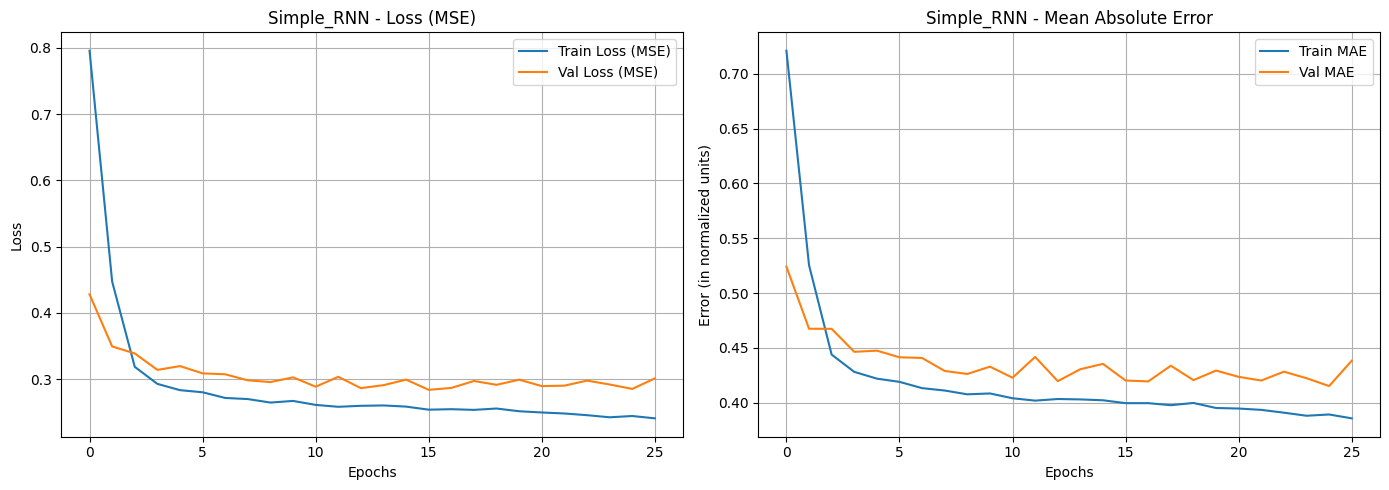

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step

--- Statistics for Simple_RNN (Real Degrees) ---
Test RMSE:       3.3991 °C
Test MAE:        2.6254 °C


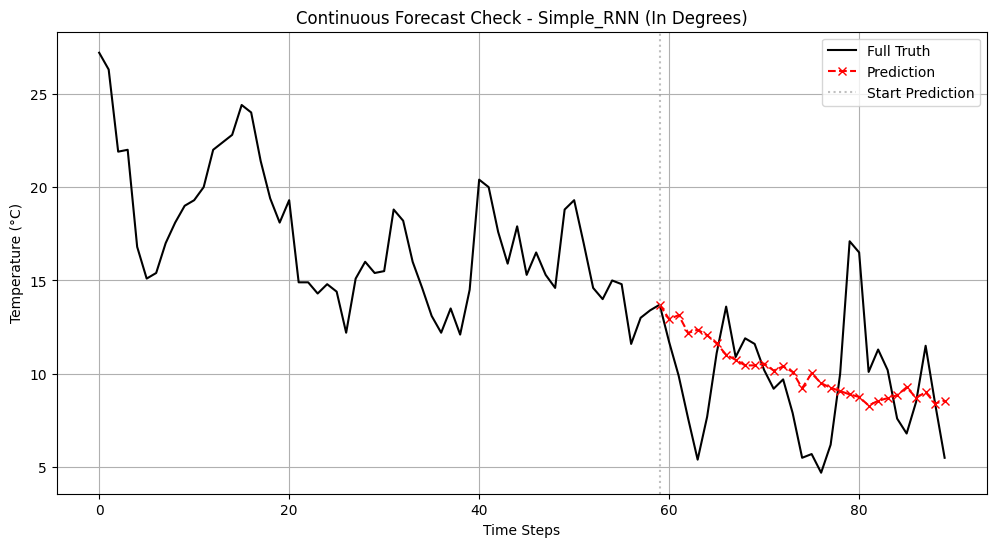


Training Model: LSTM_Vanilla
You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.
Model architecture saved as LSTM_Vanilla_architecture.png
Epoch 1/200


2025-12-15 01:32:43.519076: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-12-15 01:32:43.519128: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-12-15 01:32:43.519141: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-12-15 01:32:45.582351: I external/l

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 1.0151 - mae: 0.8285

2025-12-15 01:32:48.205492: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-12-15 01:32:48.446073: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_12', 8 bytes spill stores, 8 bytes spill loads

2025-12-15 01:32:48.826539: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_12', 532 bytes spill stores, 532 bytes spill loads



22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 119ms/step - loss: 0.9748 - mae: 0.7962 - val_loss: 0.7042 - val_mae: 0.6857
Epoch 2/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.7585 - mae: 0.7046 - val_loss: 0.5764 - val_mae: 0.6142
Epoch 3/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.8152 - mae: 0.6551 - val_loss: 0.5215 - val_mae: 0.5839
Epoch 4/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.6542 - mae: 0.6488 - val_loss: 0.3982 - val_mae: 0.5017
Epoch 5/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.5467 - mae: 0.5885 - val_loss: 0.3316 - val_mae: 0.4711
Epoch 6/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.4876 - mae: 0.5522 - val_loss: 0.2873 - val_mae: 0.4238
Epoch 7/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.4266 - mae: 0.5135 - val_loss: 0.2831 - val_mae: 0.4178
Epoch 8/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.4041 - mae: 0.5025 - val_loss: 0.2825 - val_mae: 0.4194
Epoch 9/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.3784 

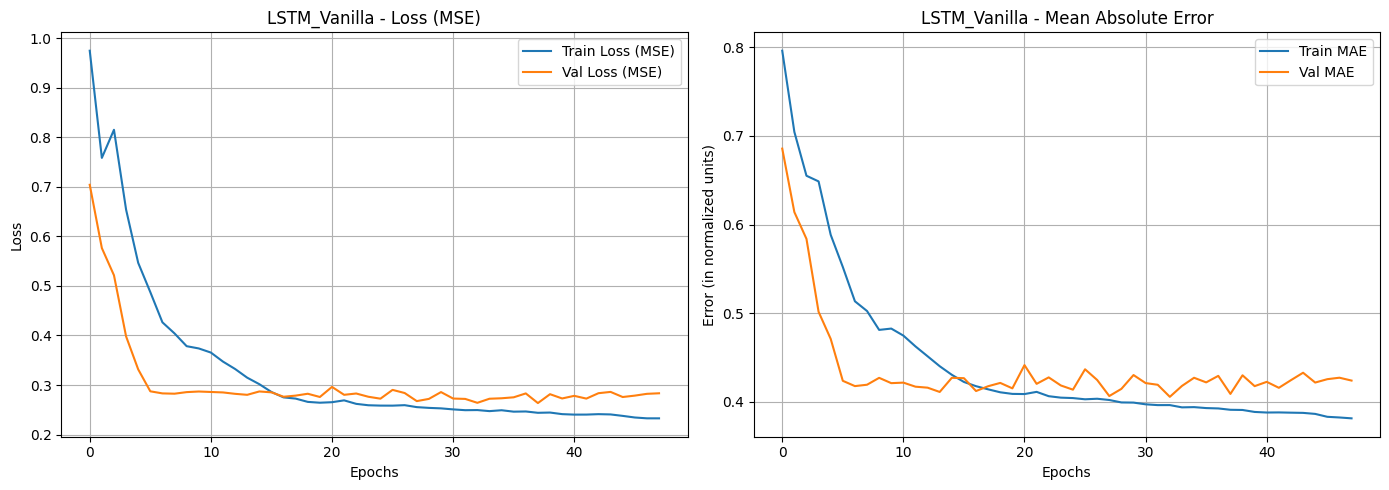

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step

--- Statistics for LSTM_Vanilla (Real Degrees) ---
Test RMSE:       3.5557 °C
Test MAE:        2.7236 °C


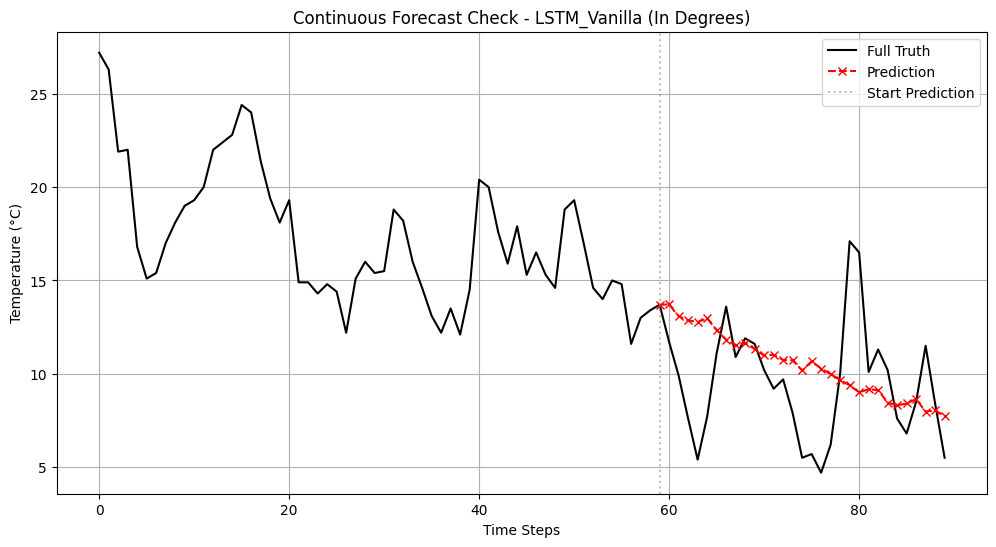


Training Model: LSTM_Stacked
You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.
Model architecture saved as LSTM_Stacked_architecture.png
Epoch 1/200


2025-12-15 01:33:09.553057: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-12-15 01:33:09.553133: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-12-15 01:33:09.553144: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-12-15 01:33:10.404147: I external/l

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - loss: 0.9687 - mae: 0.8151

2025-12-15 01:33:15.314152: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-12-15 01:33:15.314204: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-12-15 01:33:15.554016: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_27', 8 bytes spill stores, 8 bytes spill loads

2025-12-15 01:33:15.855300: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Reg

22/22 ━━━━━━━━━━━━━━━━━━━━ 8s 196ms/step - loss: 0.9271 - mae: 0.7927 - val_loss: 0.5802 - val_mae: 0.6110
Epoch 2/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 81ms/step - loss: 0.6658 - mae: 0.6411 - val_loss: 0.4097 - val_mae: 0.5071
Epoch 3/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.4522 - mae: 0.5205 - val_loss: 0.3067 - val_mae: 0.4417
Epoch 4/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.3353 - mae: 0.4532 - val_loss: 0.2779 - val_mae: 0.4171
Epoch 5/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.2976 - mae: 0.4297 - val_loss: 0.3079 - val_mae: 0.4480
Epoch 6/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.2780 - mae: 0.4162 - val_loss: 0.2929 - val_mae: 0.4300
Epoch 7/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.2704 - mae: 0.4124 - val_loss: 0.2788 - val_mae: 0.4178
Epoch 8/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.2621 - mae: 0.4061 - val_loss: 0.2857 - val_mae: 0.4247
Epoch 9/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.2613 

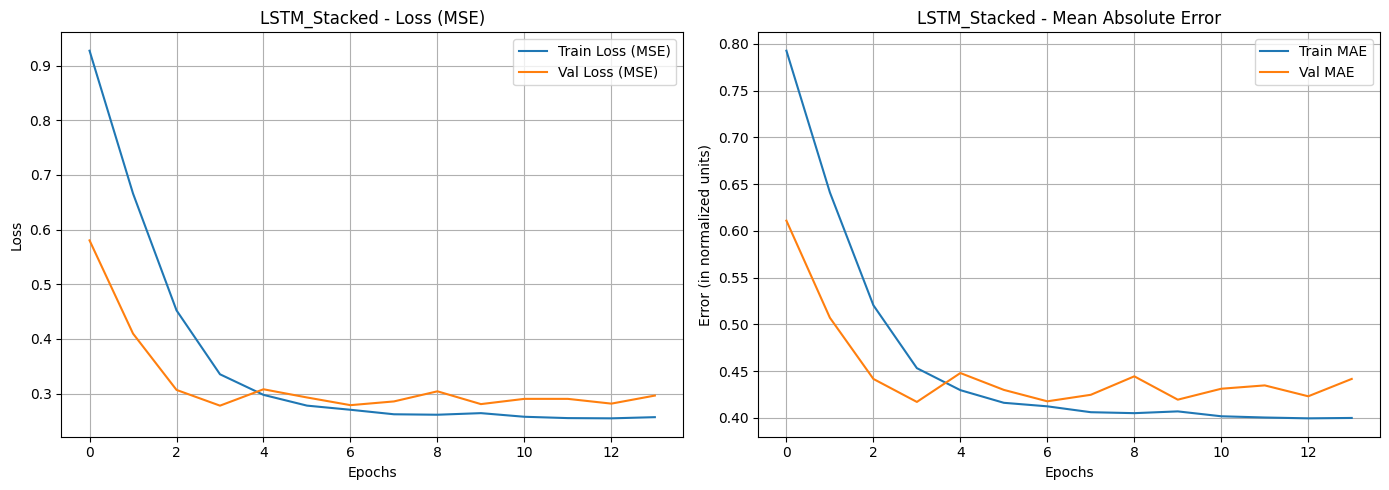

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 829ms/step

--- Statistics for LSTM_Stacked (Real Degrees) ---
Test RMSE:       3.8045 °C
Test MAE:        3.1165 °C


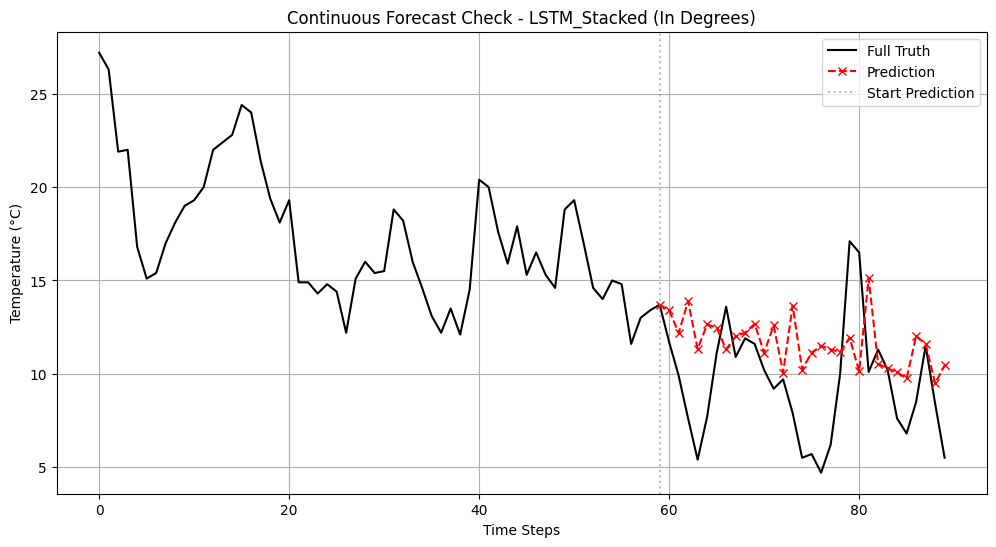


Training Model: LSTM_big
You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.
Model architecture saved as LSTM_big_architecture.png
Epoch 1/200


2025-12-15 01:33:30.265800: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-12-15 01:33:30.265847: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-12-15 01:33:30.978353: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_121', 528 bytes spill stores, 528 bytes spill loads

2025-12-15 01:33:31.097047: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning 

22/22 ━━━━━━━━━━━━━━━━━━━━ 12s 261ms/step - loss: 0.9748 - mae: 0.8210 - val_loss: 0.7697 - val_mae: 0.7295
Epoch 2/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - loss: 0.8939 - mae: 0.7730 - val_loss: 0.6115 - val_mae: 0.6306
Epoch 3/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - loss: 0.7624 - mae: 0.6999 - val_loss: 0.4608 - val_mae: 0.5494
Epoch 4/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - loss: 0.6388 - mae: 0.6301 - val_loss: 0.3950 - val_mae: 0.5156
Epoch 5/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - loss: 0.5458 - mae: 0.5745 - val_loss: 0.3349 - val_mae: 0.4729
Epoch 6/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - loss: 0.4869 - mae: 0.5419 - val_loss: 0.3099 - val_mae: 0.4489
Epoch 7/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - loss: 0.4432 - mae: 0.5157 - val_loss: 0.3068 - val_mae: 0.4476
Epoch 8/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - loss: 0.4067 - mae: 0.4951 - val_loss: 0.3079 - val_mae: 0.4547
Epoch 9/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - loss: 0.3846

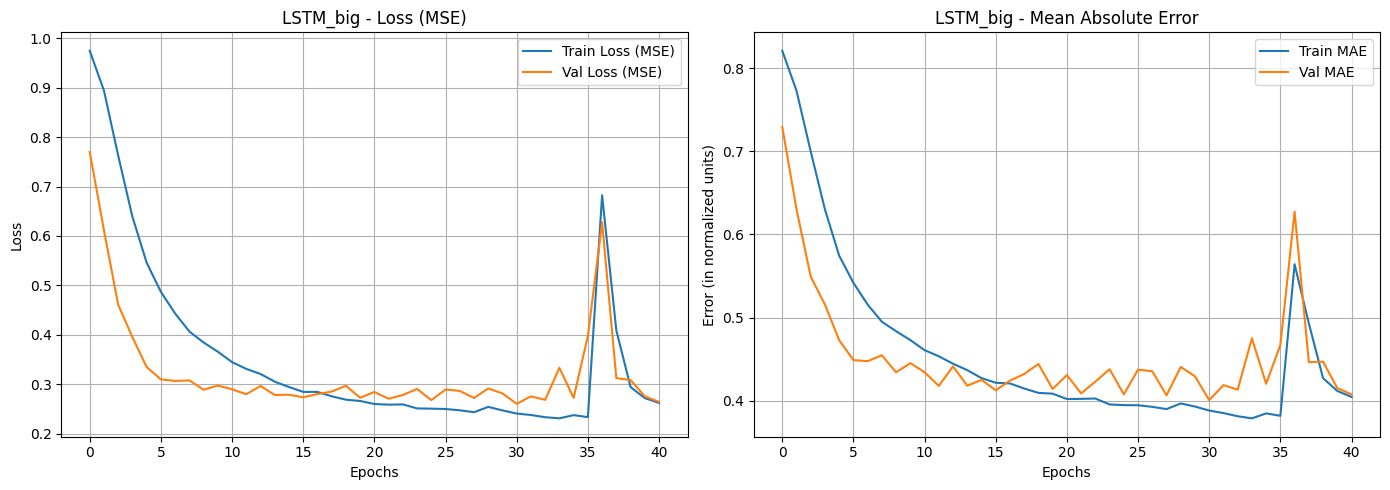

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 657ms/step

--- Statistics for LSTM_big (Real Degrees) ---
Test RMSE:       3.7223 °C
Test MAE:        2.9926 °C


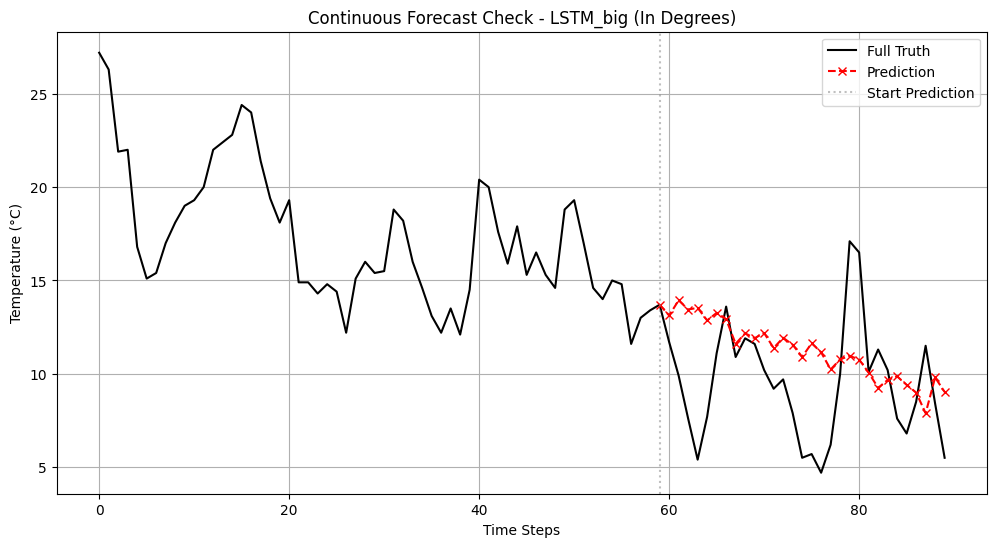


Training Model: Simple_RNN_tanh_tanh
You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.
Model architecture saved as Simple_RNN_tanh_tanh_architecture.png
Epoch 1/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 79ms/step - loss: 0.6877 - mae: 0.6458 - val_loss: 0.3903 - val_mae: 0.4928
Epoch 2/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.3339 - mae: 0.4496 - val_loss: 0.3444 - val_mae: 0.4684
Epoch 3/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.2931 - mae: 0.4243 - val_loss: 0.3388 - val_mae: 0.4645
Epoch 4/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.2759 - mae: 0.4138 - val_loss: 0.3274 - val_mae: 0.4580
Epoch 5/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.2692 - mae: 0.4105 - val_loss: 0.3162 - val_mae: 0.4487
Epoch 6/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.2657 - mae: 0.4082 - val_loss: 0.3160 - val_mae: 0.4498
Epoch 7/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.2682 - mae: 0.4

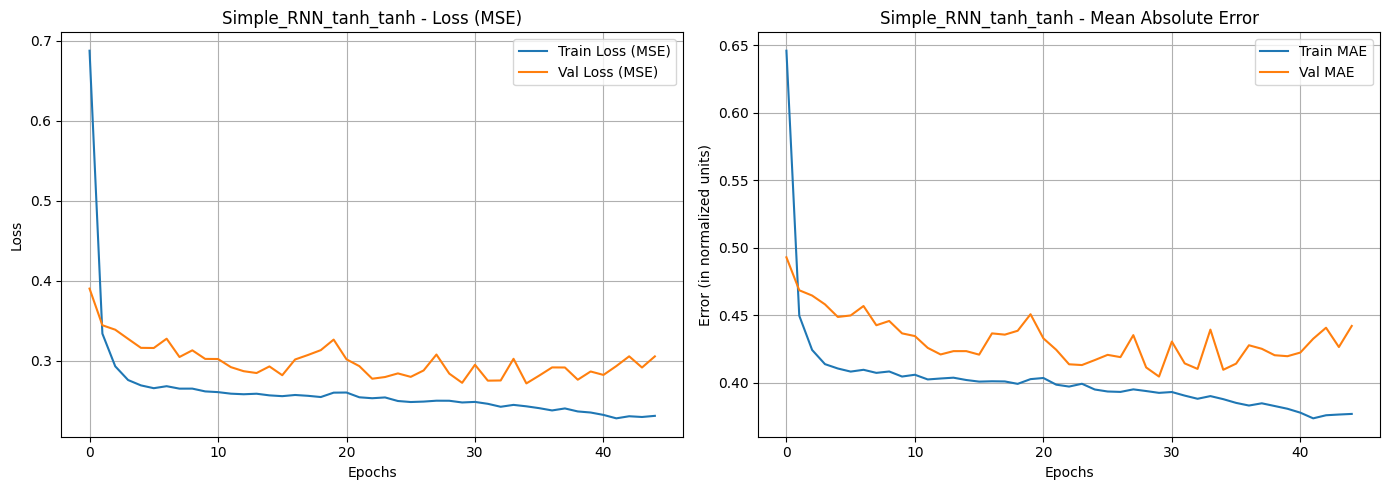

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step

--- Statistics for Simple_RNN_tanh_tanh (Real Degrees) ---
Test RMSE:       3.5867 °C
Test MAE:        2.7936 °C


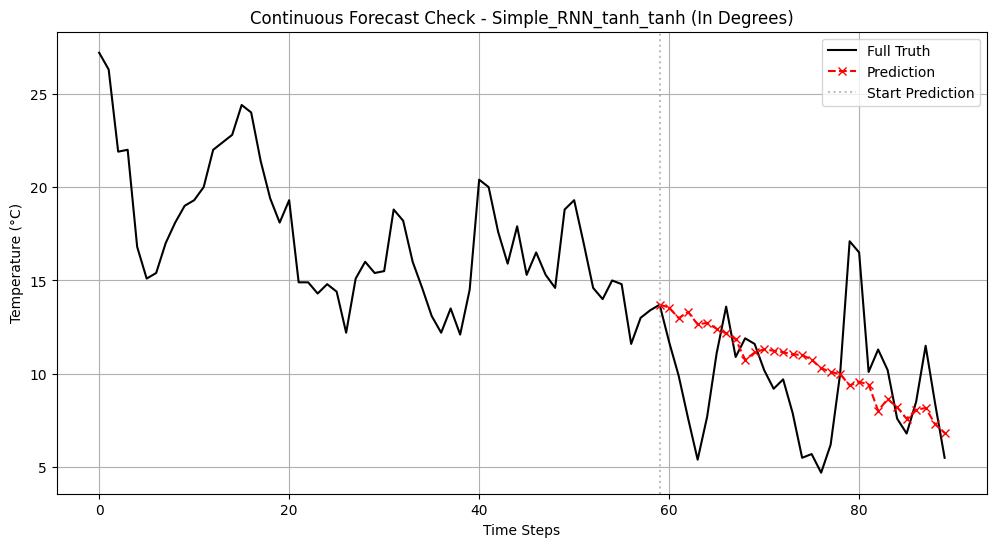


Training Model: LSTM_Vanilla_tanh
You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.
Model architecture saved as LSTM_Vanilla_tanh_architecture.png
Epoch 1/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.9416 - mae: 0.7960 - val_loss: 0.5524 - val_mae: 0.5906
Epoch 2/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.4576 - mae: 0.5254 - val_loss: 0.3548 - val_mae: 0.4736
Epoch 3/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.3083 - mae: 0.4343 - val_loss: 0.3039 - val_mae: 0.4397
Epoch 4/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.2789 - mae: 0.4174 - val_loss: 0.2911 - val_mae: 0.4317
Epoch 5/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.2717 - mae: 0.4136 - val_loss: 0.2908 - val_mae: 0.4284
Epoch 6/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.2673 - mae: 0.4111 - val_loss: 0.2871 - val_mae: 0.4224
Epoch 7/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.2629 - mae: 0.4065 - 

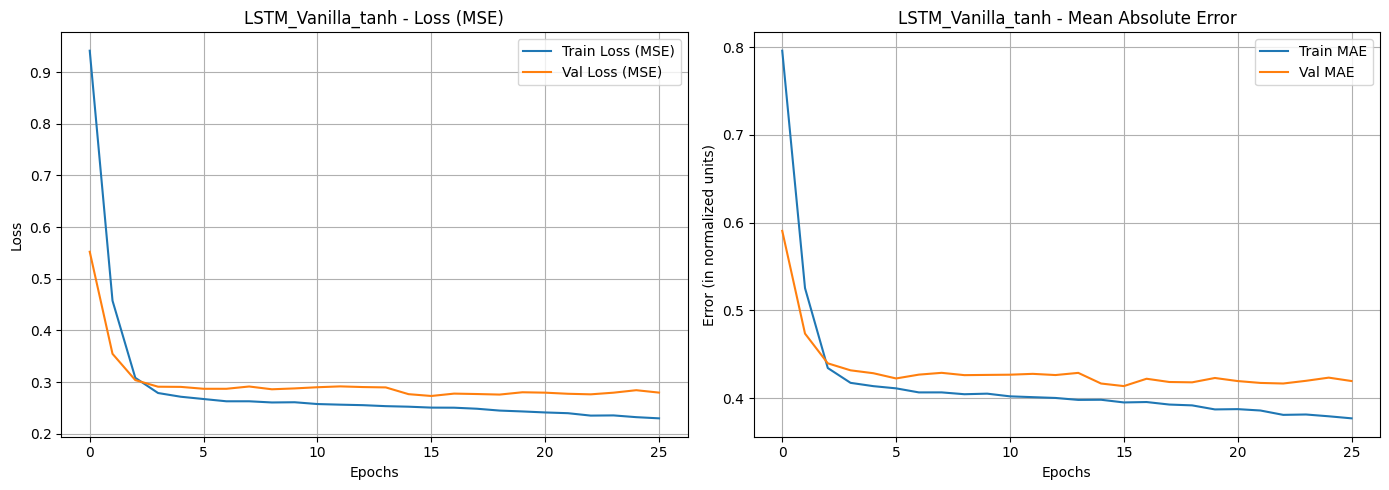

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step

--- Statistics for LSTM_Vanilla_tanh (Real Degrees) ---
Test RMSE:       3.7657 °C
Test MAE:        3.0290 °C


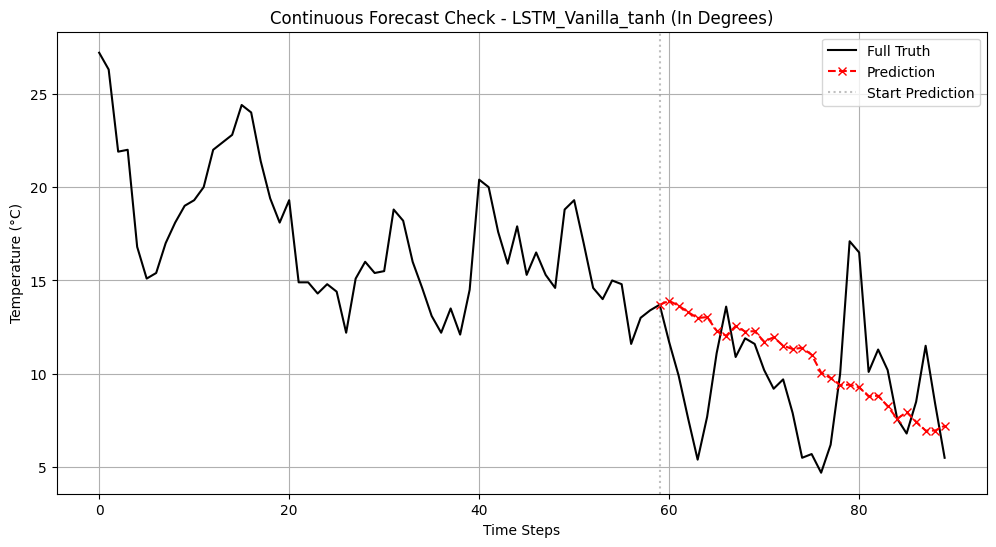


Training Model: LSTM_Stacked_tanh
You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.
Model architecture saved as LSTM_Stacked_tanh_architecture.png
Epoch 1/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.7542 - mae: 0.7017 - val_loss: 0.4229 - val_mae: 0.5062
Epoch 2/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.3980 - mae: 0.4886 - val_loss: 0.3191 - val_mae: 0.4487
Epoch 3/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.2938 - mae: 0.4248 - val_loss: 0.2963 - val_mae: 0.4337
Epoch 4/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.2767 - mae: 0.4180 - val_loss: 0.2808 - val_mae: 0.4190
Epoch 5/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.2709 - mae: 0.4133 - val_loss: 0.2947 - val_mae: 0.4294
Epoch 6/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.2678 - mae: 0.4108 - val_loss: 0.2857 - val_mae: 0.4189
Epoch 7/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.2653 - mae: 0.4088 - 

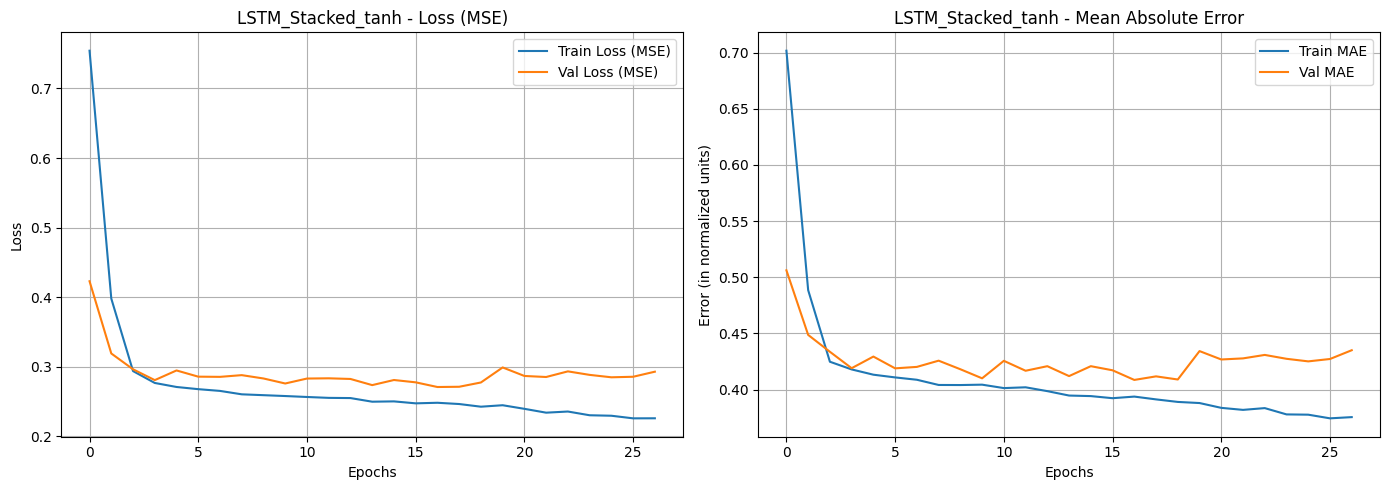

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step

--- Statistics for LSTM_Stacked_tanh (Real Degrees) ---
Test RMSE:       4.5698 °C
Test MAE:        3.8400 °C


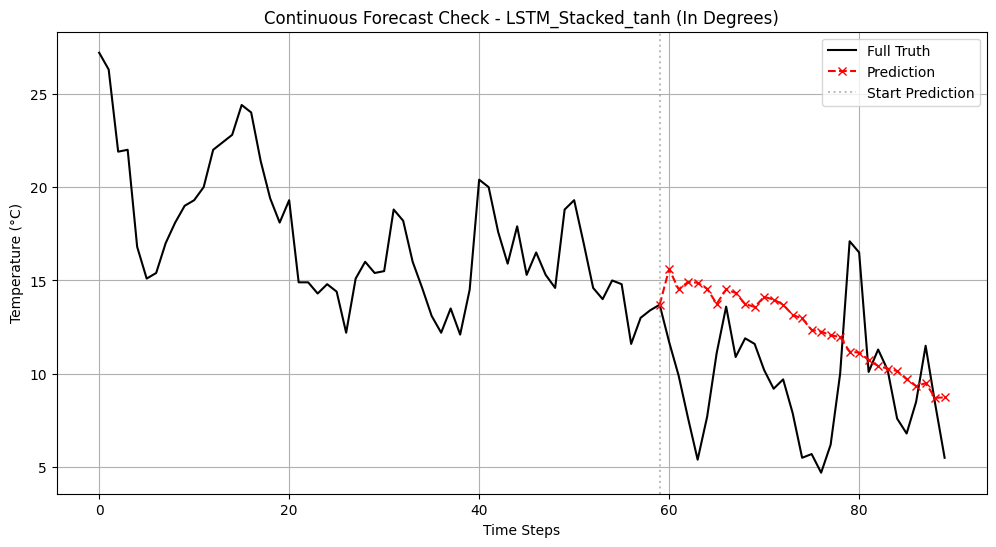


Training Model: LSTM_big_tanh
You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.
Model architecture saved as LSTM_big_tanh_architecture.png
Epoch 1/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.9082 - mae: 0.7816 - val_loss: 0.7044 - val_mae: 0.6788
Epoch 2/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.7728 - mae: 0.7042 - val_loss: 0.5944 - val_mae: 0.6121
Epoch 3/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.6464 - mae: 0.6316 - val_loss: 0.5012 - val_mae: 0.5578
Epoch 4/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.5234 - mae: 0.5585 - val_loss: 0.4303 - val_mae: 0.5169
Epoch 5/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.4309 - mae: 0.5052 - val_loss: 0.3737 - val_mae: 0.4816
Epoch 6/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.3725 - mae: 0.4725 - val_loss: 0.3445 - val_mae: 0.4654
Epoch 7/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.3325 - mae: 0.4482 - val_loss

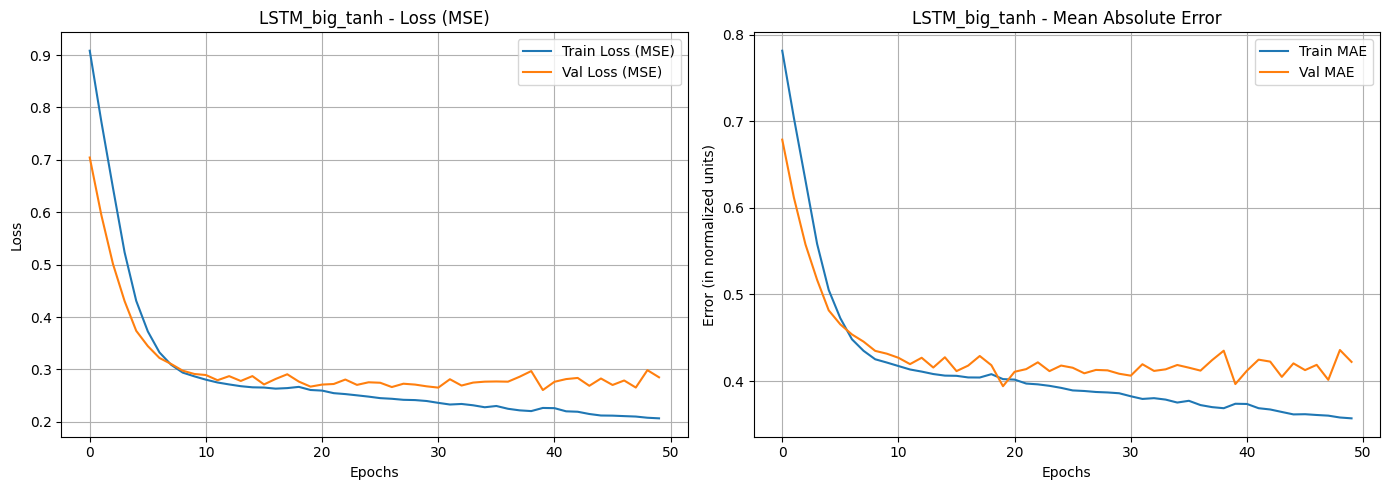

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step

--- Statistics for LSTM_big_tanh (Real Degrees) ---
Test RMSE:       3.9829 °C
Test MAE:        3.1099 °C


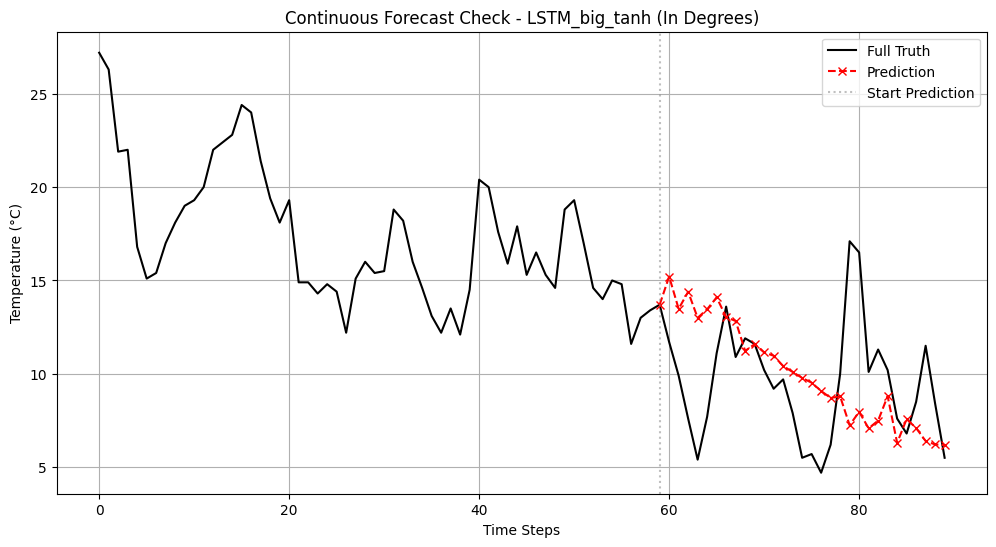


Training Model: LSTM_huge
You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.
Model architecture saved as LSTM_huge_architecture.png
Epoch 1/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - loss: 0.9175 - mae: 0.7867 - val_loss: 0.7044 - val_mae: 0.6761
Epoch 2/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.8081 - mae: 0.7216 - val_loss: 0.6070 - val_mae: 0.6181
Epoch 3/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.6846 - mae: 0.6507 - val_loss: 0.5029 - val_mae: 0.5557
Epoch 4/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.5513 - mae: 0.5737 - val_loss: 0.4340 - val_mae: 0.5178
Epoch 5/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.4544 - mae: 0.5190 - val_loss: 0.3859 - val_mae: 0.4889
Epoch 6/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.3880 - mae: 0.4805 - val_loss: 0.3500 - val_mae: 0.4740
Epoch 7/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.3432 - mae: 0.4527 - val_loss: 0.3249

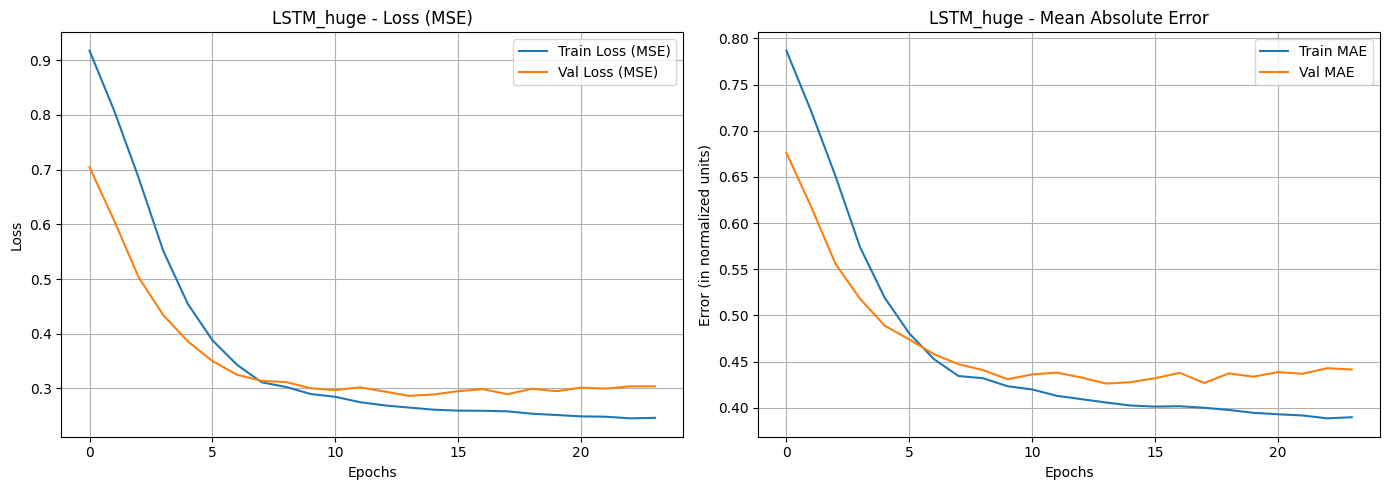

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step

--- Statistics for LSTM_huge (Real Degrees) ---
Test RMSE:       3.6529 °C
Test MAE:        2.8046 °C


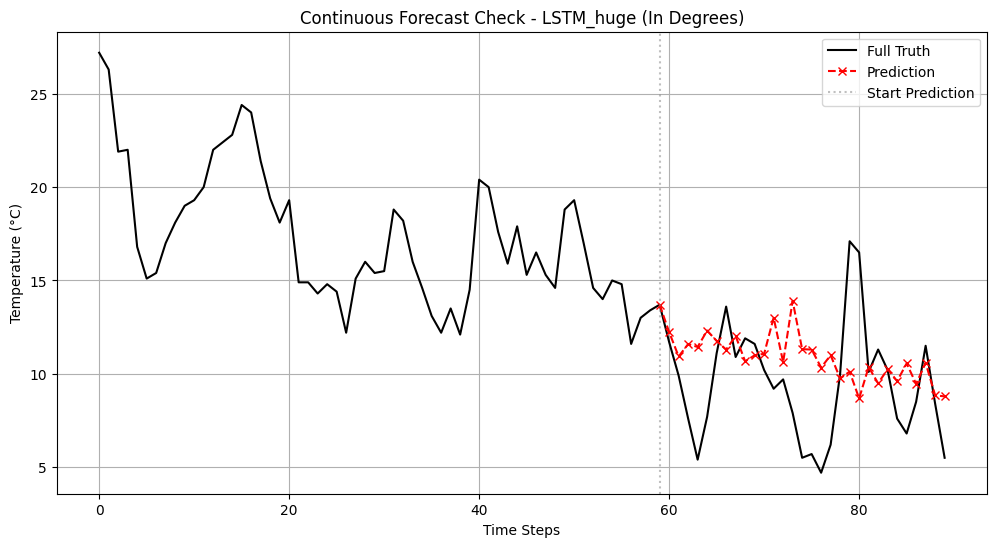


Training Model: LSTM_biggest
You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.
Model architecture saved as LSTM_biggest_architecture.png
Epoch 1/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 9s 129ms/step - loss: 0.8219 - mae: 0.7398 - val_loss: 0.4272 - val_mae: 0.5112
Epoch 2/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - loss: 0.4673 - mae: 0.5356 - val_loss: 0.4150 - val_mae: 0.5031
Epoch 3/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - loss: 0.4379 - mae: 0.5166 - val_loss: 0.4152 - val_mae: 0.5032
Epoch 4/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - loss: 0.4119 - mae: 0.4971 - val_loss: 0.4299 - val_mae: 0.5139
Epoch 5/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - loss: 0.3679 - mae: 0.4651 - val_loss: 0.4652 - val_mae: 0.5420
Epoch 6/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - loss: 0.3719 - mae: 0.4701 - val_loss: 0.4186 - val_mae: 0.5102
Epoch 7/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - loss: 0.3567 - mae: 0.4590 - val_loss:

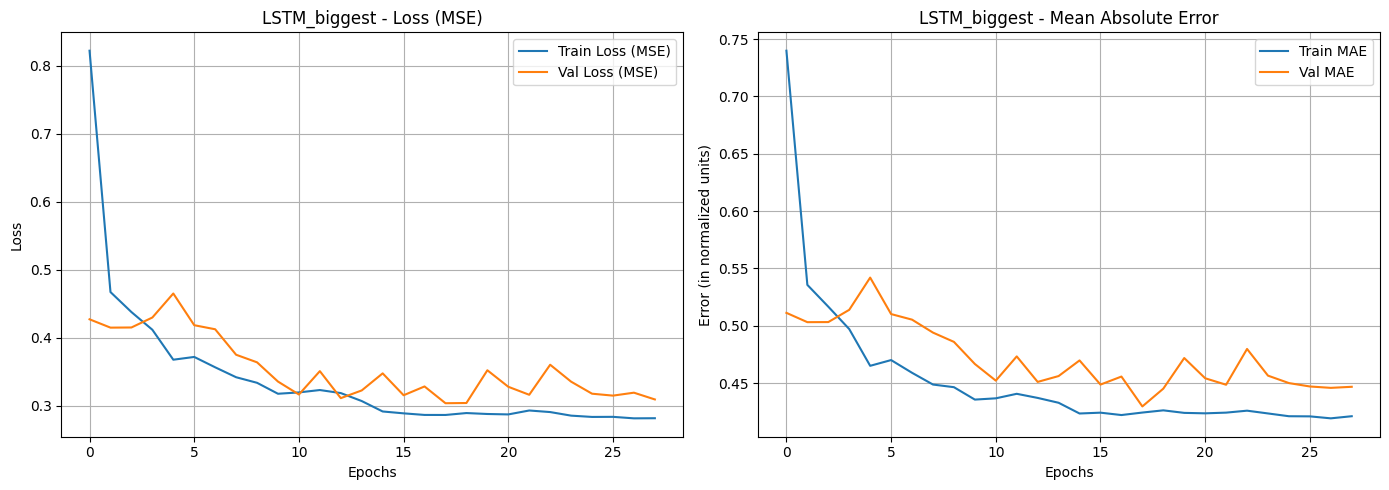

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 545ms/step

--- Statistics for LSTM_biggest (Real Degrees) ---
Test RMSE:       3.0851 °C
Test MAE:        2.4205 °C


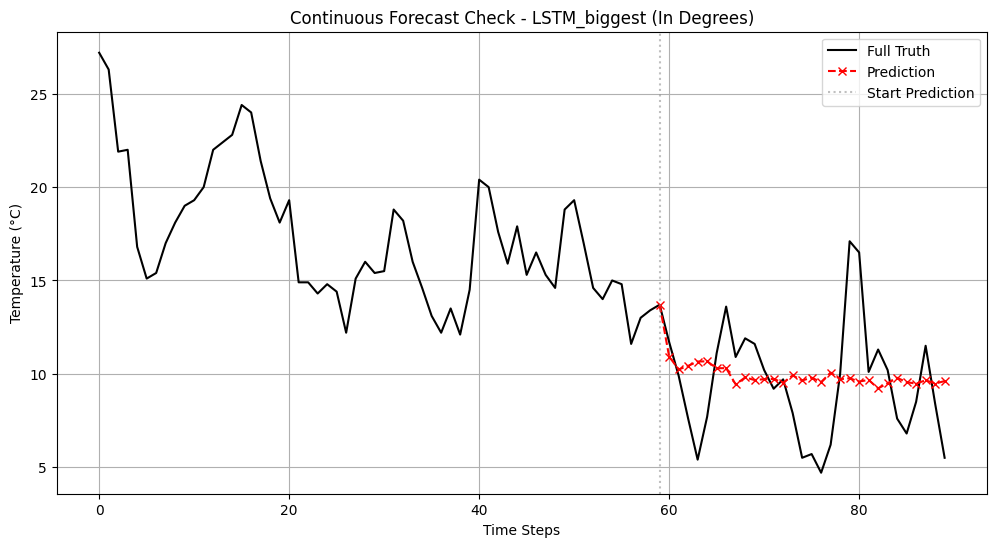


FINAL RESULTS SUMMARY
               Model       MSE     RMSE      MAE     Loss
          Simple_RNN 11.553988 3.399116 2.625432 0.234527
        LSTM_Vanilla 12.643074 3.555710 2.723636 0.256634
        LSTM_Stacked 14.474513 3.804538 3.116507 0.293809
            LSTM_big 13.855163 3.722252 2.992594 0.281237
Simple_RNN_tanh_tanh 12.864349 3.586690 2.793583 0.261125
   LSTM_Vanilla_tanh 14.180847 3.765746 3.029025 0.287848
   LSTM_Stacked_tanh 20.883356 4.569831 3.839955 0.423898
       LSTM_big_tanh 15.863117 3.982853 3.109930 0.321996
           LSTM_huge 13.343501 3.652876 2.804551 0.270851
        LSTM_biggest  9.517580 3.085057 2.420543 0.193191


In [35]:
for model in models:
    results_summary.append( train_and_evaluate(model, X_train, y_train, X_val, y_val, X_test, y_test,scaler))


print("\n" + "="*40)
print("FINAL RESULTS SUMMARY")
print("="*40)
df_results = pd.DataFrame(results_summary)
print(df_results.to_string(index=False))